### Step 1: Mount the Google Drive

Remember to use GPU runtime before mounting your Google Drive. (Runtime --> Change runtime type).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 2: Open the project directory

Replace `Your_Dir` with your own path.

In [2]:
# clone the repo into Colab
!rm -rf ECE_C147A_Final
!GIT_LFS_SKIP_SMUDGE=1 git clone -b FFT https://github.com/DysonLewis/ECE_C147A_Final.git

'''
from google.colab import files
files.upload()
!mv generic.ckpt /content/ECE_C147A_Final/Project/emg2qwerty/models/
'''

Cloning into 'ECE_C147A_Final'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 166 (delta 20), reused 23 (delta 6), pack-reused 104 (from 1)
Receiving objects: 100% (166/166), 33.56 MiB | 18.46 MiB/s, done.
Resolving deltas: 100% (29/29), done.


'\nfrom google.colab import files\nfiles.upload()\n!mv generic.ckpt /content/ECE_C147A_Final/Project/emg2qwerty/models/\n'

### Step 3: Install required packages

After installing them, Colab will require you to restart the session.

In [3]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty

!mkdir data/

!cp /content/drive/MyDrive/data/* /content/ECE_C147A_Final/Project/emg2qwerty/data/

/content/ECE_C147A_Final/Project/emg2qwerty


In [10]:
!pip install -r requirements.txt

  Using cached https://github.com/kpu/kenlm/archive/master.zip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 7.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of typer to determine which version is compatible with o

### Step 4: Start your experiments!

- Remember to download and copy the dataset to this directory: `Your_Dir/emg2qwerty/data`.
- You may now start your experiments with any scripts! Below are examples of single-user training and testing (greedy decoding).
- **There are two ways to track the logs:**
  - 1. Keep `--multirun`, and the logs will not be printed here, but they will be saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/submitit_logs/`.
  - 2. Comment out `--multirun` and the logs will be printed in this notebook, but they will not be saved.

#### Training

- The checkpoints are saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/checkpoints/`.

In [1]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty

/content/ECE_C147A_Final/Project/emg2qwerty


In [ ]:
# Single-user training

!python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu trainer.devices=1 \
  trainer.max_epochs=50 \
  batch_size=64 \
  num_workers=8 \
  optimizer.lr=0.0015 \
  +trainer.log_every_n_steps=5
  #--multirun

/content/ECE_C147A_Final/Project/emg2qwerty
[2026-03-06 01:19:15,962][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-

#### Fourier Features Training

The Nyquist verification prints how much signal power would be aliased at each downsample factor.

In [2]:
from pathlib import Path
import h5py
import numpy as np

data_dir = Path('data')
hdf5_files = sorted(data_dir.glob('*.hdf5'))

fs = 2000
with h5py.File(hdf5_files[0], 'r') as f:
    emg = f['emg2qwerty']['timeseries']['emg_left'][:10000, 0]

freqs = np.fft.rfftfreq(len(emg), d=1.0 / fs)
psd   = np.abs(np.fft.rfft(emg)) ** 2
total = psd.sum()

semg_pct = 100 * psd[(freqs >= 20) & (freqs <= 500)].sum() / total
print(f'Power in 20-500 Hz sEMG band: {semg_pct:.1f}% of total\n')
print(f'{"Factor":<8} {"Effective fs":<15} {"Aliased power %":<18} {"Status"}')
print('-' * 58)
for factor in [1, 2, 4, 8]:
    eff_fs  = fs // factor
    aliased = 100 * psd[freqs > (eff_fs / 2)].sum() / total
    status  = 'safe' if factor <= 2 else 'violates Nyquist'
    print(f'{factor:<8} {eff_fs:<15} {aliased:<18.2f} {status}')

Power in 20-500 Hz sEMG band: 97.0% of total

Factor   Effective fs    Aliased power %    Status
----------------------------------------------------------
1        2000            0.00               safe
2        1000            2.91               safe
4        500             14.30              violates Nyquist
8        250             45.85              violates Nyquist


In [ ]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty
import time, json, threading, subprocess
import pandas as pd
import psutil
from pathlib import Path

def sample_memory(samples, stop_event, interval=60):
    while not stop_event.is_set():
        ram_gb = psutil.virtual_memory().used / 1e9
        try:
            smi = subprocess.check_output(
                ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
                text=True
            )
            vram_mb = int(smi.strip())
        except Exception:
            vram_mb = None
        samples.append({
            "elapsed_min": round((time.time() - samples[0]["t0"]) / 60, 2) if samples else 0,
            "ram_gb": round(ram_gb, 2),
            "vram_mb": vram_mb,
            "t0": samples[0]["t0"] if samples else time.time(),
        })
        stop_event.wait(interval)

configs = [
    {"name": "hop16_no_resample",  "resample": 1, "hop_length": 16},
    {"name": "hop8_no_resample",   "resample": 1, "hop_length": 8},
    {"name": "hop12_no_resample",  "resample": 1, "hop_length": 12},
    {"name": "hop4_resample2",     "resample": 2, "hop_length": 4},
    {"name": "hop6_resample2",     "resample": 2, "hop_length": 6},
]

results = {}

for cfg in configs:
    print(f"Running {cfg['name']}")
    start = time.time()

    # start memory sampler
    samples = [{"elapsed_min": 0, "ram_gb": 0, "vram_mb": 0, "t0": start}]
    stop_event = threading.Event()
    monitor = threading.Thread(target=sample_memory, args=(samples, stop_event), daemon=True)
    monitor.start()

    !python -m emg2qwerty.train \
        user="single_user" \
        transforms=fourier_features \
        resample.factor={cfg['resample']} \
        fourier.hop_length={cfg['hop_length']} \
        dataset.root=data \
        trainer.accelerator=gpu trainer.devices=1 \
        +trainer.max_time="00:00:45:00" \
        batch_size=64 \
        num_workers=8 \
        optimizer.lr=0.0015 \
        +trainer.log_every_n_steps=5 \
        hydra.run.dir=logs/{cfg['name']}

    stop_event.set()
    elapsed = time.time() - start

    # grab sample closest to 20 min
    valid = [s for s in samples if "ram_gb" in s and s["elapsed_min"] > 0]
    midpoint = min(valid, key=lambda s: abs(s["elapsed_min"] - 20)) if valid else {}

    results[cfg['name']] = {
        "config": cfg,
        "time_min": round(elapsed / 60, 2),
        "memory_at_20min": {
            "elapsed_min": midpoint.get("elapsed_min"),
            "ram_gb":      midpoint.get("ram_gb"),
            "vram_mb":     midpoint.get("vram_mb"),
        },
        "memory_all_samples": [{k: v for k, v in s.items() if k != "t0"} for s in valid],
        "per_epoch": {},
        "test": [],
    }
    print(f"  Done in {elapsed/60:.2f} min | RAM: {midpoint.get('ram_gb')}GB | VRAM: {midpoint.get('vram_mb')}MB")

with open("sampling_rate_results_full.json", "w") as f:
    json.dump(results, f, indent=2)

print("Results saved to sampling_rate_results_full.json")

/content/ECE_C147A_Final/Project/emg2qwerty
Running hop16_no_resample
[2026-03-07 17:14:40,206][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-

KeyError: 'hop16_no_resample'

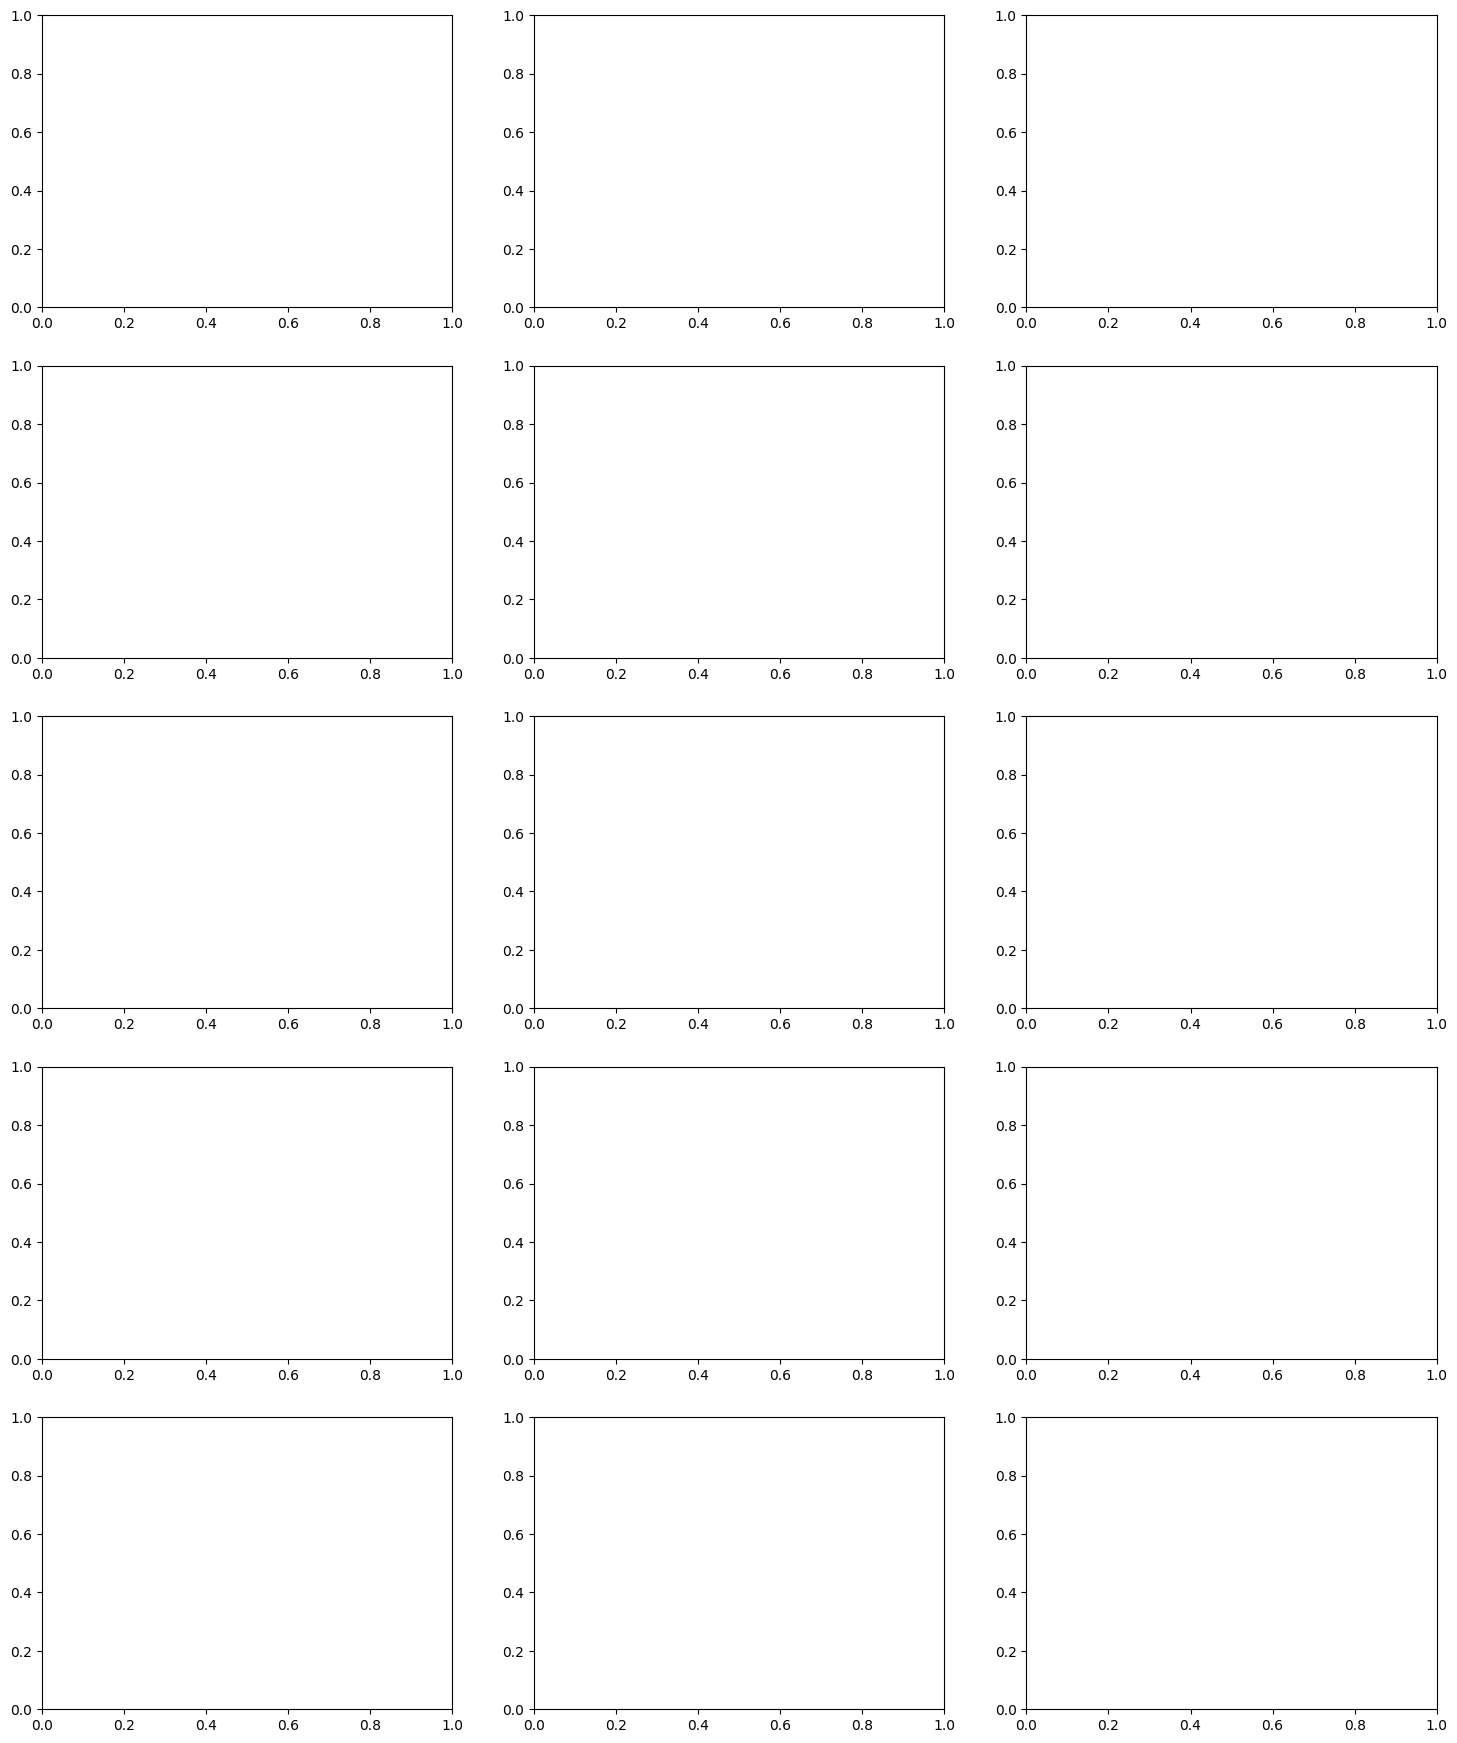

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

configs = ["hop16_no_resample", "hop8_no_resample", "hop12_no_resample", "hop4_resample2", "hop6_resample2"]
base = Path("/content/ECE_C147A_Final/Project/emg2qwerty/logs")

results = json.load(open("sampling_rate_results_full.json"))

def diagnose(train_vals, val_vals, metric):
    issues = []
    if len(train_vals) < 5 or len(val_vals) < 5:
        return ["insufficient data"]

    train   = np.array(train_vals)
    val     = np.array(val_vals)
    min_len = min(len(train), len(val))
    train   = train[:min_len]
    val     = val[:min_len]
    gap     = val - train

    # overfitting: val diverging upward from train
    if metric != "loss":
        late_gap  = gap[-10:].mean()
        early_gap = gap[:10].mean()
        if late_gap > early_gap + 5:
            issues.append(f"overfitting (gap grew +{late_gap - early_gap:.1f})")
    else:
        late_gap  = gap[-10:].mean()
        early_gap = gap[:10].mean()
        if late_gap > early_gap + 0.1:
            issues.append(f"overfitting (loss gap grew +{late_gap - early_gap:.2f})")

    # underfitting: val CER still high and not plateaued
    if metric == "CER":
        if val[-1] > 40 and (val[-10] - val[-1]) > 1:
            issues.append(f"underfitting (val CER still {val[-1]:.1f}% and declining)")
        elif val[-1] > 40:
            issues.append(f"high CER plateau ({val[-1]:.1f}%) - may need architecture change")

    # not converged: still improving at end
    if (val[-10] - val[-1]) / (abs(val[-1]) + 1e-6) > 0.05:
        issues.append("not converged (still improving, run longer)")

    # plateaued early
    if len(val) > 20:
        mid_improvement = val[len(val)//2] - val[-1]
        if abs(mid_improvement) < 0.5 and metric == "CER":
            issues.append(f"plateaued early at epoch ~{len(val)//2}")

    return issues if issues else ["looks healthy"]

metrics = ["CER", "IER", "DER", "SER", "loss"]
fig, axes = plt.subplots(len(metrics), len(configs), figsize=(18, 22))

for col, name in enumerate(configs):
    for row, metric in enumerate(metrics):
        ax = axes[row][col]

        for phase, color in [("train", "steelblue"), ("val", "darkorange")]:
            data = results[name][phase].get(metric, [])
            if not data:
                continue
            # convert steps to approximate epochs
            steps  = np.array([d["step"] for d in data])
            values = np.array([d["value"] for d in data])
            epochs = np.arange(1, len(steps) + 1)
            ax.plot(epochs, values, label=phase, color=color, linewidth=1.5)

        # test metric as horizontal dashed line
        test_data = results[name]["test"].get(metric, [])
        if test_data:
            ax.axhline(test_data[-1]["value"], color="red", linestyle="--", linewidth=1, label=f"test ({test_data[-1]['value']:.1f})")

        if row == 0:
            ax.set_title(name, fontsize=11, fontweight="bold")
        if col == 0:
            ax.set_ylabel(metric, fontsize=10)
        ax.set_xlabel("Epoch")
        ax.legend(fontsize=7)

        # diagnosis annotation
        train_vals = [d["value"] for d in results[name]["train"].get(metric, [])]
        val_vals   = [d["value"] for d in results[name]["val"].get(metric, [])]
        if train_vals and val_vals:
            issues = diagnose(train_vals, val_vals, metric)
            color  = "red" if any(k in i for i in issues for k in ["overfitting", "high CER", "underfitting"]) else \
                     "darkorange" if any("converged" in i or "plateaued" in i for i in issues) else "green"
            ax.annotate("\n".join(issues), xy=(0.02, 0.97), xycoords="axes fraction",
                        fontsize=6.5, va="top", color=color,
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))

print("\nFinal Metrics Summary")
print("=" * 70)
for name in configs:
    print(f"\n{name}")
    print(f"  {'Metric':<10} {'Train':>10} {'Val':>10} {'Test':>10}")
    print(f"  {'-'*40}")
    for metric in metrics:
        train_val = results[name]["train"].get(metric, [])
        val_val   = results[name]["val"].get(metric, [])
        test_val  = results[name]["test"].get(metric, [])
        t = f"{train_val[-1]['value']:.2f}" if train_val else "N/A"
        v = f"{val_val[-1]['value']:.2f}"   if val_val   else "N/A"
        te = f"{test_val[-1]['value']:.2f}" if test_val  else "N/A"
        print(f"  {metric:<10} {t:>10} {v:>10} {te:>10}")

plt.tight_layout()
plt.savefig("sampling_rate_curves.png", dpi=150)
plt.show()
print("Saved sampling_rate_curves.png")

#### Testing:

- Replace `Your_Path_to_Checkpoint` with your checkpoint path.

In [ ]:
import os
os.environ["HYDRA_FULL_ERROR"] = "1"

In [ ]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty
!python -m emg2qwerty.train \
  user="single_user" \
  "checkpoint='/content/ECE_C147A_Final/Project/emg2qwerty/logs/2026-03-05/23-26-11/checkpoints/epoch=49-step=2000.ckpt'" \
  train=false trainer.accelerator=gpu \
  decoder=ctc_greedy

/content/ECE_C147A_Final/Project/emg2qwerty
[2026-03-05 23:59:05,166][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-